# Proyecto Integrador (TC5035)
# Identificación de Gestos en el Lenguaje de Manos Mexicano
# Avance 4. Modelos alternativos
---
## EQUIPO 51
- CARLOS MIGUEL ARVIZU DURÁN - A01410682
- YOHANNA CEBALLOS SALOMÓN - A01795115
- RUBÉN DÍAZ GARCÍA - A01371849

## Profesores
- PROFESOR ASESOR: DR. RAÚL VALENTE RAMÍREZ VELARDE
- PROFESORA TITULAR: DRA. GRETTEL BARCELÓ ALONSO
- PROFESOR TITULAR: DR. LUIS EDUARDO FALCÓN MORALES
- PROFESORA ASISTENTE: MTRA. VERÓNICA SANDRA GUZMÁN DE VALLE

---

## Librerías

In [1]:
import os
import cv2
import mediapipe as mp
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.utils import to_categorical
from tqdm import tqdm

## Función para Carga de Datos

In [2]:
# Estructura esperada: videos/{class_id}-{class_name}/{video_id}.mp4
# Escanea las carpetas con los videos en la estructura esperada y crea un dataframe
def create_dataframe_from_folders(videos_dir):
    rows = []
    print(f"Escaneando '{videos_dir}'...")

    if not os.path.isdir(videos_dir):
        print(f"Error: El directorio '{videos_dir}' no existe.")
        return pd.DataFrame()

    # Itera sobre cada subdirectorio en la carpeta de videos
    for folder_name in sorted(os.listdir(videos_dir)):
        folder_path = os.path.join(videos_dir, folder_name)

        if os.path.isdir(folder_path):
            try:
                # Se extrae el ID y el nombre de la clase del nombre de la carpeta
                class_id, class_name = folder_name.split('-', 1)
            except ValueError:
                print(f" Carpeta omitida: '{folder_name}'")
                continue

            # Itera sobre cada archivo dentro de la carpeta de la clase
            for video_file in os.listdir(folder_path):
                if video_file.endswith('.mp4'):
                    video_id = video_file.split('.')[0]
                    
                    video_path = os.path.join(folder_path, video_file)
                    rows.append({
                        'class_id': class_id,   # Columna para el ID
                        'class': class_name,    # Columna para la clase
                        'video_id': video_id,   # Columna para el nombre
                        'video_path': video_path
                    })
    
    if not rows:
        print("Error: No se encontraron videos.")
        return pd.DataFrame()

    df = pd.DataFrame(rows)
    print(f"DataFrame creado! \nContiene {len(df)} videos de {df['class'].nunique()} clases distintas.")
    return df

## Funciones para Extracción de Características

In [3]:
class FeatureExtractor:
    def __init__(self):
        self.mp_hands = mp.solutions.hands
        self.hands = self.mp_hands.Hands(
            static_image_mode=False,
            max_num_hands=2,
            min_detection_confidence=0.5,
            min_tracking_confidence=0.5
        )
        # El vector de características por frame tendrá 21 (puntos) * 3 (coords) * 2 (manos) = 126
        self.feature_vector_size = 21 * 3 * 2

    #Procesa un video y extrae los 21 puntos de referencia 3D de hasta 2 manos por frame
    def extract_hand_keypoints(self, video_path):
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            print(f"Error: No se pudo abrir el video {video_path}")
            return None

        video_keypoints = []
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break

            # Procesamiento con MediaPipe
            image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = self.hands.process(image_rgb)
            frame_keypoints = np.zeros(self.feature_vector_size)

            if results.multi_hand_landmarks:
                # Itera sobre cada mano detectada
                for i, hand_landmarks in enumerate(results.multi_hand_landmarks):
                    if i >= 2: continue # Limitación para 2 manos
                    # Extrae los landmarks y los aplana en un array
                    landmarks = np.array(
                        [[lm.x, lm.y, lm.z] for lm in hand_landmarks.landmark]
                    ).flatten()
                    # Asigna los landmarks al array del frame
                    # Mano 0: índices 0-62, Mano 1: índices 63-125
                    start_index = i * (21 * 3)
                    end_index = start_index + len(landmarks)
                    frame_keypoints[start_index:end_index] = landmarks
            video_keypoints.append(frame_keypoints)
        cap.release()
        return np.array(video_keypoints)

    # Calculamos la velocidad (diferencia entre frames).
    def calculate_kinematic_features(self, keypoints_sequence):
        # Si hay menos de 2 frames, no se puede calcular velocidad
        if keypoints_sequence.shape[0] < 2:
            return np.zeros_like(keypoints_sequence)
        # Calcula la diferencia entre frames consecutivos para obtener la velocidad
        velocities = np.diff(keypoints_sequence, axis=0)
        # Añade un frame de velocidad cero al principio para mantener la misma longitud
        velocities = np.vstack([np.zeros(velocities.shape[1]), velocities])
        return velocities

    # Función de extracción de características 
    def process_video(self, video_path):
        # Extracción de puntos de referencia
        keypoints = self.extract_hand_keypoints(video_path)
        if keypoints is None or keypoints.shape[0] == 0:
            return None
        # Generación de nuevas características (velocidad)
        velocities = self.calculate_kinematic_features(keypoints)
        # Combinar las características (coordenadas + velocidad)
        combined_features = np.hstack([keypoints, velocities])
        
        return combined_features

In [4]:
class VideoFeatureExtractor(BaseEstimator, TransformerMixin):
    def __init__(self):
        # Inicializa una sola vez para evitar recargar el modelo de MediaPipe
        self.extractor = FeatureExtractor()

    def fit(self, X, y=None):
        # Este transformador no necesita "aprender" nada, así que solo devuelve self
        return self

    # X: lista o serie de Pandas con rutas a los videos
    def transform(self, X, y=None):
        all_sequences = []
        print("Paso 1/3: Extrayendo características de los videos...")
        for video_path in tqdm(X, desc="Extrayendo secuencias"):
            features = self.extractor.process_video(video_path)
            # Solo añade secuencias válidas
            if features is not None and features.shape[0] > 0:
                all_sequences.append(features)
        return all_sequences

# Estandariza la longitud de las secuencias mediante padding
class SequencePadder(BaseEstimator, TransformerMixin):
    def __init__(self, percentile=95):
        self.percentile = percentile
        self.target_frames_ = 0

    # Aprende la longitud objetivo a partir de los datos de entrenamiento
    def fit(self, X, y=None):
        sequence_lengths = [seq.shape[0] for seq in X]
        if sequence_lengths:
            self.target_frames_ = int(np.percentile(sequence_lengths, self.percentile))
        print(f"Longitud de secuencia objetivo aprendida: {self.target_frames_} fotogramas.")
        return self

    # Aplica padding a cada secuencia en X.
    def transform(self, X, y=None):
        print("Paso 2/3: Estandarizando longitud de secuencias...")
        processed_sequences = []
        for seq in tqdm(X, desc="Padding"):
            num_frames, num_features = seq.shape
            
            if num_frames > self.target_frames_:
                processed_seq = seq[:self.target_frames_, :]
            elif num_frames < self.target_frames_:
                pad_width = self.target_frames_ - num_frames
                padding = np.zeros((pad_width, num_features))
                processed_seq = np.vstack([seq, padding])
            else:
                processed_seq = seq
            
            processed_sequences.append(processed_seq)
        return np.array(processed_sequences)

# Aplicamos transformadores a nivel de característica a datos 3D temporales
class TemporalFeatureProcessor(BaseEstimator, TransformerMixin):
    def __init__(self, n_components=0.95):
        self.n_components = n_components
        # Define un pipeline interno para el procesamiento de características
        self.feature_pipeline_ = Pipeline([
            ('scaler', MinMaxScaler()),
            ('pca', PCA(n_components=self.n_components))
        ])

    # Ajusta el pipeline de características en los datos aplanados
    def fit(self, X, y=None):
        n_videos, n_frames, n_features = X.shape
        # Aplana los datos a 2D para ajustar el scaler y PCA
        reshaped_data = X.reshape(-1, n_features)
        self.feature_pipeline_.fit(reshaped_data)
        print("Scaler y PCA ajustados.")
        return self

    # Aplica el pipeline de características y devuelve los datos en formato 3D
    def transform(self, X, y=None):
        print("Paso 3/3: Aplicando Scaler y PCA a nivel de fotograma...")
        n_videos, n_frames, n_features = X.shape
        # Aplana, transforma y luego remodela de vuelta a 3D
        reshaped_data = X.reshape(-1, n_features)
        transformed_data = self.feature_pipeline_.transform(reshaped_data)
        
        # El número de características ahora es el número de componentes de PCA
        n_transformed_features = transformed_data.shape[1]
        final_data = transformed_data.reshape(n_videos, n_frames, n_transformed_features)
        
        print(f"Características reducidas a {n_transformed_features} componentes.")
        return final_data

## Preprocesamiento

In [5]:
# CONFIGURACIÓN: se debe ajustar a la carpeta desde donde se corre el programa
notebook_dir = Path.cwd() 
current_script_dir = notebook_dir#.parent
parent_dir = current_script_dir
PROCESSED_DATA_DIR = parent_dir / "processed_data_pipeline"
data_dir = parent_dir / "data"
VIDEOS_DIR =  data_dir / "videos"

print(f"\nPaths: \nPROCESSED DATA DIRECTORY: {PROCESSED_DATA_DIR} \nVIDEOS DIRECTORY: {VIDEOS_DIR}")


Paths: 
PROCESSED DATA DIRECTORY: /Users/raven/Documents/Code/MNA/lsm/TC5035-PI-E51/Avance4/processed_data_pipeline 
VIDEOS DIRECTORY: /Users/raven/Documents/Code/MNA/lsm/TC5035-PI-E51/Avance4/data/videos


In [ ]:
# --- Cargar metadatos ---
print("--- Carga de Metadatos desde Carpetas ---")
df = create_dataframe_from_folders(VIDEOS_DIR)

if df.empty:
    print("No se encontraron datos para procesar.")
    exit()

# Separar características (X) y etiquetas (y)
X = df['video_path']
y = df['class']

# Dividir los datos ANTES del preprocesamiento para evitar fuga de datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

print(f"\nDatos divididos: {len(X_train)} para entrenamiento, {len(X_test)} para prueba.")

--- Carga de Metadatos desde Carpetas ---
Escaneando '/Users/raven/Documents/Code/MNA/lsm/TC5035-PI-E51/Avance4/data/videos'...
DataFrame creado! 
Contiene 205 videos de 4 clases distintas.

Datos divididos: 143 para entrenamiento, 41 para prueba.


In [7]:
# --- Definir el Pipeline de Preprocesamiento ---
print("\n--- Definición del Pipeline ---")

preprocessing_pipeline = Pipeline([
    ('1_video_feature_extraction', VideoFeatureExtractor()),
    ('2_sequence_padding', SequencePadder(percentile=95)),
    ('3_feature_processing', TemporalFeatureProcessor(n_components=0.95))
])


--- Definición del Pipeline ---


I0000 00:00:1760917764.667229 12711932 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M2 Pro


In [8]:
# --- Ejecutar el Pipeline ---
print("\n--- Ejecutando el Pipeline en los Datos de Entrenamiento ---")
# Ajusta el pipeline con los datos de entrenamiento y guarda el pipeline ajustado
fitted_pipeline = preprocessing_pipeline.fit(X_train)
# Ahora, usa el pipeline ya ajustado para transformar los datos
X_train_processed = fitted_pipeline.transform(X_train)

print("\n--- Ejecutando el Pipeline en los Datos de Prueba ---")
# Solo transforma los datos de prueba (usando los parámetros aprendidos del entrenamiento)
X_test_processed = fitted_pipeline.transform(X_test)

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.



--- Ejecutando el Pipeline en los Datos de Entrenamiento ---
Paso 1/3: Extrayendo características de los videos...


W0000 00:00:1760917764.687404 12712442 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
Extrayendo secuencias:   0%|                                                                                                                                 | 0/164 [00:00<?, ?it/s]W0000 00:00:1760917764.693809 12712445 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
/Users/raven/anaconda3/envs/lsm/lib/python3.10/site-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
Extrayendo secuencias: 100%|██████████████████████████████████████████████████████████████████████████████████████████

Longitud de secuencia objetivo aprendida: 150 fotogramas.
Paso 2/3: Estandarizando longitud de secuencias...


Padding: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 164/164 [00:00<00:00, 2071885.11it/s]


...

Paso 3/3: Aplicando Scaler y PCA a nivel de fotograma...
Características reducidas a 5 componentes.

--- Ejecutando el Pipeline en los Datos de Prueba ---
Paso 1/3: Extrayendo características de los videos...


Extrayendo secuencias:   0%|                                                                                                                                  | 0/41 [00:00<?, ?it/s]/Users/raven/anaconda3/envs/lsm/lib/python3.10/site-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
Extrayendo secuencias: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 41/41 [02:25<00:00,  3.56s/it]


Paso 2/3: Estandarizando longitud de secuencias...


Padding: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 41/41 [00:00<00:00, 1074790.40it/s]

Paso 3/3: Aplicando Scaler y PCA a nivel de fotograma...
Características reducidas a 5 componentes.


## Guardar los Resultados

In [9]:
# --- Guardar los resultados ---
print("\n--- Guardando los Datos Procesados ---")
output_dir = "processed_data_pipeline"
os.makedirs(output_dir, exist_ok=True)

# Guardar datos de entrenamiento
np.save(os.path.join(output_dir, "X_train.npy"), X_train_processed)
y_train.to_csv(os.path.join(output_dir, "y_train.csv"), index=False, header=True)

# Guardar datos de prueba
np.save(os.path.join(output_dir, "X_test.npy"), X_test_processed)
y_test.to_csv(os.path.join(output_dir, "y_test.csv"), index=False, header=True)

print(f"\nProcesamiento completado!")
print(f"Datos guardados en la carpeta '{output_dir}'.")
print(f"Forma de los datos de entrenamiento (X_train.npy): {X_train_processed.shape}")
print(f"Forma de los datos de prueba (X_test.npy): {X_test_processed.shape}")


--- Guardando los Datos Procesados ---

Procesamiento completado!
Datos guardados en la carpeta 'processed_data_pipeline'.
Forma de los datos de entrenamiento (X_train.npy): (164, 150, 5)
Forma de los datos de prueba (X_test.npy): (41, 150, 5)


## Análisis de PCA

--- Gráfico para análisis de PCA ---

Número de componentes seleccionados por PCA: 5
Varianza total explicada: 95.51%

Generando la gráfica de varianza explicada...


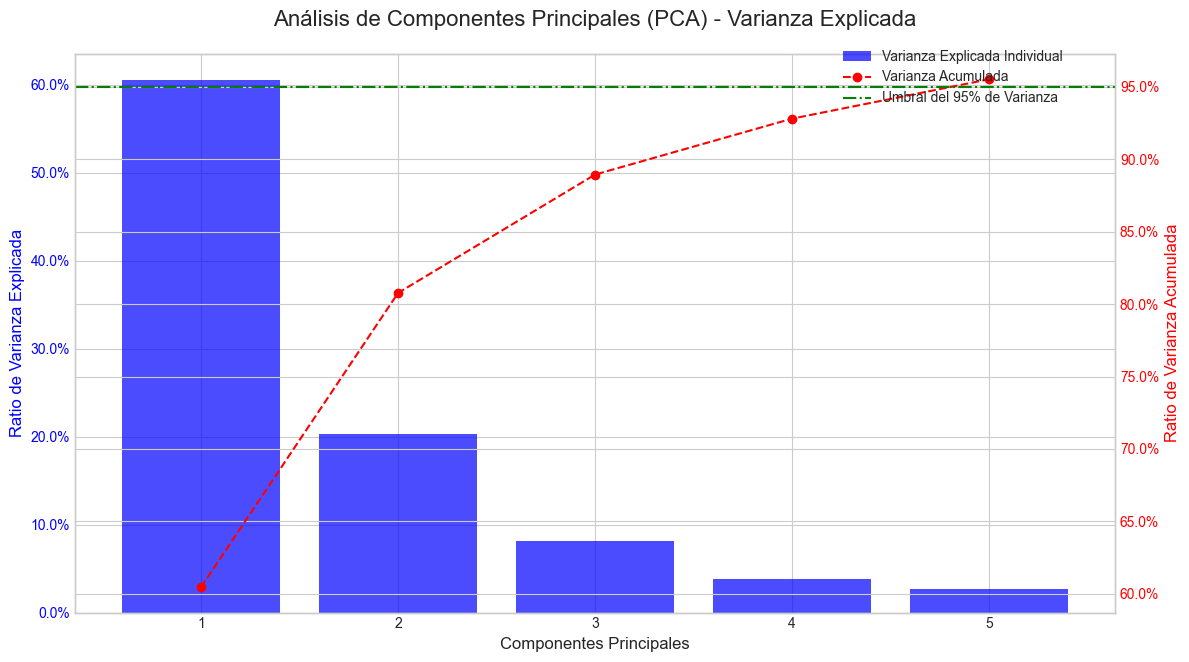

In [10]:
# --- Visualizando PCA ---

print("--- Gráfico para análisis de PCA ---")

pca_model = fitted_pipeline.named_steps['3_feature_processing'].feature_pipeline_.named_steps['pca']
explained_variance = pca_model.explained_variance_ratio_

print(f"\nNúmero de componentes seleccionados por PCA: {len(explained_variance)}")
print(f"Varianza total explicada: {sum(explained_variance):.2%}")

print("\nGenerando la gráfica de varianza explicada...")
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax1 = plt.subplots(figsize=(12, 7))

components = np.arange(1, len(explained_variance) + 1)
ax1.bar(components, explained_variance, alpha=0.7, color='b', label='Varianza Explicada Individual')
ax1.set_xlabel('Componentes Principales', fontsize=12)
ax1.set_ylabel('Ratio de Varianza Explicada', color='b', fontsize=12)
ax1.tick_params(axis='y', labelcolor='b')
ax1.set_xticks(components)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))

ax2 = ax1.twinx()
cumulative_variance = np.cumsum(explained_variance)
ax2.plot(components, cumulative_variance, color='r', marker='o', linestyle='--', label='Varianza Acumulada')
ax2.set_ylabel('Ratio de Varianza Acumulada', color='r', fontsize=12)
ax2.tick_params(axis='y', labelcolor='r')
ax2.axhline(y=0.95, color='g', linestyle='-.', label='Umbral del 95% de Varianza')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))

plt.title('Análisis de Componentes Principales (PCA) - Varianza Explicada', fontsize=16, pad=20)
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.9))
plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()